# Week 2 — FITS files, TESS data products, and light-curve basics

This notebook works with **δ Orionis (Mintaka)**, a bright **eclipsing / spectroscopic binary** observed by TESS. It:

1. Resolves the target in the **TIC** and finds **2-minute cadence** TESS timeseries observations via **MAST**.
2. Downloads the **Target Pixel File** (`*_tp.fits`) and the matching **SPOC light curve** (`*_lc.fits`) for one sector.
3. Builds a **simple manual aperture** from the median flux image and sums **FLUX** through that mask (classic aperture photometry).
4. Compares the result to **SPOC SAP_FLUX** (and optionally to photometry using the pipeline aperture bitmask from the FITS **APERTURE** extension).

References: [TESS Science Data Products](https://archive.stsci.edu/missions-and-data/tess), [SPOC data descriptions](https://heasarc.gsfc.nasa.gov/docs/tess/data-handling.html).

In [16]:
%matplotlib inline

from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astroquery.mast import Catalogs, Observations

## 1. Resolve the star in the TIC

A cone search can return **several** TIC rows near Orion’s belt. We sort by **T magnitude** and keep the **brightest** entry (for δ Ori / Mintaka this is typically **TIC 50743458** in the TIC). Some MAST observations only ship **data-validation (DV)** products; the download step below skips those and picks the first sector that actually exposes **`_tp.fits`** and **`_lc.fits`**.

In [17]:
star_name = "del Ori"

tic = Catalogs.query_object(star_name, catalog="Tic")
tic.sort("Tmag")
tic_id = int(tic["ID"][0])
coord = SkyCoord(ra=tic["ra"][0] * u.deg, dec=tic["dec"][0] * u.deg)

print(f"Brightest TIC match: {tic_id}  (T_mag ≈ {float(tic['Tmag'][0]):.3f})")
coord

Brightest TIC match: 50743458  (T_mag ≈ 7.005)


<SkyCoord (ICRS): (ra, dec) in deg
    (83.00169288, -0.28454051)>

## 2. Find 2-minute TESS timeseries observations

We restrict to **`timeseries`**, **`TESS`**, and **`t_exptime == 120` s** so we do not pick up full-frame-image (FFI) stacks. We then keep rows whose **`obs_id` contains the zero-padded TIC id**, so the downloaded products belong to our chosen source.

In [18]:
obs_region = Observations.query_region(coord, radius=0.002 * u.deg)
tess_2min = obs_region[
    (obs_region["obs_collection"] == "TESS")
    & (obs_region["dataproduct_type"] == "timeseries")
    & (obs_region["t_exptime"] == 120)
]

tic_token = f"{tic_id:010d}"
on_target = np.array([tic_token in str(oid) for oid in tess_2min["obs_id"]])
tess_use = tess_2min[on_target] if on_target.any() else tess_2min

tess_use.sort("obs_id")
tess_use["obs_id", "obsid", "t_exptime"]

obs_id,obsid,t_exptime
str73,str9,float64
tess2018206190142-s0001-s0036-0000000050743458,61531623,120.0
tess2018349182500-s0006-0000000050743458-0126-s,62247614,120.0
tess2020324010417-s0032-0000000050743458-0200-s,28135402,120.0


## 3. Download TPF and light curve from the same observation

Products are written under **`mast_data/`** in this repo (so runs are self-contained). The first table row is used by default; change **`obs_index`** to another sector.

In [19]:
def observation_has_tpf_and_lc(obsid):
    prod = Observations.get_product_list(obsid)
    names = prod["productFilename"].astype(str)
    return any(n.endswith("_tp.fits") for n in names) and any(
        n.endswith("_lc.fits") for n in names
    )


download_root = Path("mast_data")
download_root.mkdir(parents=True, exist_ok=True)

obs_row = None
for i in range(len(tess_use)):
    if observation_has_tpf_and_lc(tess_use["obsid"][i]):
        obs_row = tess_use[i]
        obs_index = i
        break
if obs_row is None:
    raise RuntimeError(
        "No TESS 2-min observation with both a target-pixel file and light curve was found."
    )
print(f"Using observation index {obs_index}: {obs_row['obs_id']}")

products = Observations.get_product_list(obs_row["obsid"])

names = products["productFilename"].astype(str)
pick = [n.endswith("_tp.fits") or n.endswith("_lc.fits") for n in names]
manifest = Observations.download_products(
    products[pick], download_dir=str(download_root), mrp_only=False
)
manifest

Using observation index 1: tess2018349182500-s0006-0000000050743458-0126-s
INFO: Found cached file mast_data/mastDownload/TESS/tess2018349182500-s0006-0000000050743458-0126-s/tess2018349182500-s0006-0000000050743458-0126-s_lc.fits with expected size 1598400. [astroquery.query]
INFO: Found cached file mast_data/mastDownload/TESS/tess2018349182500-s0006-0000000050743458-0126-s/tess2018349182500-s0006-0000000050743458-0126-s_tp.fits with expected size 45316800. [astroquery.query]


Local Path,Status,Message,URL
str131,str8,object,object
mast_data/mastDownload/TESS/tess2018349182500-s0006-0000000050743458-0126-s/tess2018349182500-s0006-0000000050743458-0126-s_lc.fits,COMPLETE,None,None
mast_data/mastDownload/TESS/tess2018349182500-s0006-0000000050743458-0126-s/tess2018349182500-s0006-0000000050743458-0126-s_tp.fits,COMPLETE,None,None


## 4. FITS layout: pixels, cadence metadata, and aperture image

The **PIXELS** extension holds per-cadence **`FLUX`** images (shape given by **`TDIMn`** in the header, often something like 25×61 for TESS). The **APERTURE** extension stores a bitmask per pixel; **bit 1 (value 2)** marks pixels that belong to the **pipeline optimal aperture** used for SAP.

In [20]:
local_paths = [Path(p) for p in manifest["Local Path"]]
tp_path = next(p for p in local_paths if p.name.endswith("_tp.fits"))
lc_path = next(p for p in local_paths if p.name.endswith("_lc.fits"))
print("TPF:", tp_path)
print("LC: ", lc_path)

fits.open(tp_path).info()

TPF: mast_data/mastDownload/TESS/tess2018349182500-s0006-0000000050743458-0126-s/tess2018349182500-s0006-0000000050743458-0126-s_tp.fits
LC:  mast_data/mastDownload/TESS/tess2018349182500-s0006-0000000050743458-0126-s/tess2018349182500-s0006-0000000050743458-0126-s_lc.fits
Filename: mast_data/mastDownload/TESS/tess2018349182500-s0006-0000000050743458-0126-s/tess2018349182500-s0006-0000000050743458-0126-s_tp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  PIXELS        1 BinTableHDU    248   15678R x 11C   [D, E, J, 143J, 143E, 143E, 143E, 143E, J, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 13)   int32   
  3  TARGET COSMIC RAY    1 BinTableHDU     27   0R x 4C   [J, I, I, E]   


## 5. Manual aperture from the median flux image

We median-stack an early stretch of **good-quality** cadences, locate the **brightest pixel**, and define a **square aperture** of half-width **`box_half`** (pixels). That is intentionally simpler than the pipeline’s optimal aperture.

Cadences: 15678, stamp shape: 13 × 11


/var/folders/58/mw50tngd6b1fxhfpw2qp2xpw0000gn/T/ipykernel_98358/1778952633.py:36: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(


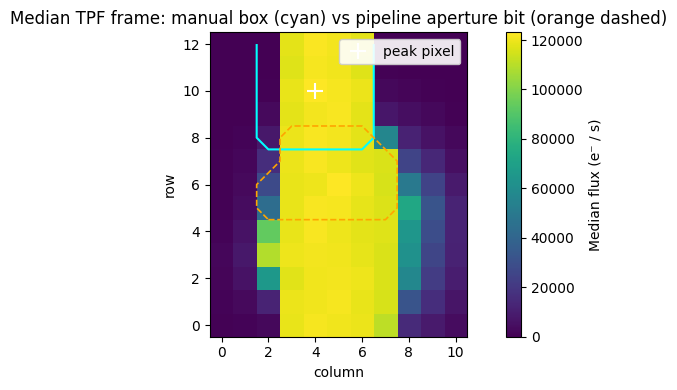

In [21]:
with fits.open(tp_path, memmap=True) as hdul:
    pix = hdul["PIXELS"].data
    ap_img = hdul["APERTURE"].data

time = np.asarray(pix["TIME"], dtype=float)
flux_cube = np.asarray(pix["FLUX"], dtype=float)  # (n_cad, nrow, ncol)
quality = np.asarray(pix["QUALITY"], dtype=np.int32)
cadence_tpf = np.asarray(pix["CADENCENO"], dtype=np.int64)

n_cad, nrow, ncol = flux_cube.shape
print(f"Cadences: {n_cad}, stamp shape: {nrow} × {ncol}")

# TESS quality flag 0 = nominal for quick cleaning (stricter masks are possible).
good = (quality == 0) & np.isfinite(time)
n_med = min(500, int(good.sum()))
median_frame = np.nanmedian(flux_cube[good][:n_med], axis=0)

r_peak, c_peak = np.unravel_index(np.nanargmax(median_frame), median_frame.shape)
box_half = 2  # pixels; try 1–3

manual_mask = np.zeros((nrow, ncol), dtype=bool)
r0, r1 = max(0, r_peak - box_half), min(nrow, r_peak + box_half + 1)
c0, c1 = max(0, c_peak - box_half), min(ncol, c_peak + box_half + 1)
manual_mask[r0:r1, c0:c1] = True

pipeline_mask = (ap_img & 2) != 0

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    median_frame,
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
)
plt.colorbar(im, ax=ax, label="Median flux (e⁻ / s)")
ax.contour(
    manual_mask.astype(float),
    levels=[0.5],
    colors="cyan",
    linewidths=1.5,
    label="manual box",
)
ax.contour(
    pipeline_mask.astype(float),
    levels=[0.5],
    colors="orange",
    linewidths=1.2,
    linestyles="--",
)
ax.plot(
    [c_peak],
    [r_peak],
    "w+",
    ms=12,
    mew=1.5,
    label="peak pixel",
)
ax.set_title("Median TPF frame: manual box (cyan) vs pipeline aperture bit (orange dashed)")
ax.set_xlabel("column")
ax.set_ylabel("row")
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()

## 6. Extract light curves: sum in aperture per cadence

**Manual LC:** \( \sum_{(i,j) \in \mathrm{mask}} \mathrm{FLUX}_{ij} \) per cadence. **Pipeline-mask LC:** same sum over pixels with bitmask bit 1 set (should be very close to **SAP_FLUX**).

In [22]:
manual_flux = np.nansum(flux_cube * manual_mask, axis=(1, 2))
pipeline_flux_from_tpf = np.nansum(flux_cube * pipeline_mask, axis=(1, 2))

with fits.open(lc_path) as hdul:
    lc = hdul["LIGHTCURVE"].data

sap_flux = np.asarray(lc["SAP_FLUX"], dtype=float)
pdc_flux = np.asarray(lc["PDCSAP_FLUX"], dtype=float)
cadence_lc = np.asarray(lc["CADENCENO"], dtype=np.int64)

idx_map = {int(c): i for i, c in enumerate(cadence_lc)}
lc_row = np.array([idx_map.get(int(c), -1) for c in cadence_tpf], dtype=np.int64)
missing = lc_row < 0
if missing.any():
    print(f"Warning: {missing.sum()} TPF cadences have no matching row in the LC file")

sap_flux = np.where(lc_row >= 0, sap_flux[lc_row], np.nan)
pdc_flux = np.where(lc_row >= 0, pdc_flux[lc_row], np.nan)

## 7. Compare to SPOC

Curves are divided by their **robust median** so eclipses and overall trends are visible on the same scale. **SAP_FLUX** should track the **pipeline-mask sum from the TPF**; the **hand-drawn box** can differ (aperture shape, neighbor stars, and background).

Median ratio (pipeline-mask TPF sum / SAP_FLUX): 1.000000


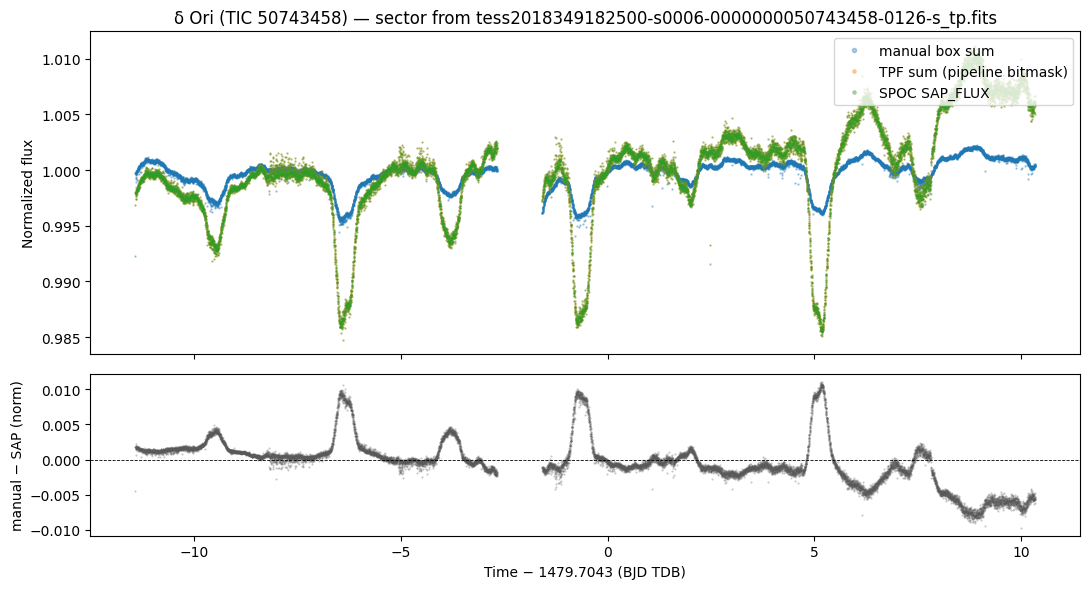

In [23]:
def norm_med(x):
    x = np.asarray(x, dtype=float)
    m = np.nanmedian(x[np.isfinite(x)])
    return x / m


t0 = np.nanmedian(time[np.isfinite(time)])
use = np.isfinite(time) & np.isfinite(manual_flux) & np.isfinite(sap_flux)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(
    time[use] - t0,
    norm_med(manual_flux[use]),
    ".",
    ms=1.5,
    alpha=0.35,
    label="manual box sum",
)
axes[0].plot(
    time[use] - t0,
    norm_med(pipeline_flux_from_tpf[use]),
    ".",
    ms=1.2,
    alpha=0.35,
    label="TPF sum (pipeline bitmask)",
)
axes[0].plot(
    time[use] - t0,
    norm_med(sap_flux[use]),
    ".",
    ms=1.2,
    alpha=0.35,
    label="SPOC SAP_FLUX",
)
axes[0].set_ylabel("Normalized flux")
axes[0].legend(markerscale=4, loc="upper right")
axes[0].set_title(f"δ Ori (TIC {tic_id}) — sector from {tp_path.name}")

ratio = norm_med(manual_flux[use]) - norm_med(sap_flux[use])
axes[1].plot(time[use] - t0, ratio, ".", ms=1, alpha=0.35, color="0.35")
axes[1].axhline(0, color="k", lw=0.6, ls="--")
axes[1].set_xlabel(f"Time − {t0:.4f} (BJD TDB)")
axes[1].set_ylabel("manual − SAP (norm)")

plt.tight_layout()

finite = np.isfinite(pipeline_flux_from_tpf) & np.isfinite(sap_flux)
if finite.sum() > 10:
    rel = pipeline_flux_from_tpf[finite] / sap_flux[finite]
    print(
        f"Median ratio (pipeline-mask TPF sum / SAP_FLUX): {np.nanmedian(rel):.6f}"
    )

### Optional: PDC-corrected SPOC curve

**PDCSAP_FLUX** applies cotrending against systematic vectors; it is often the cleanest for variability science but is **not** a raw aperture sum.

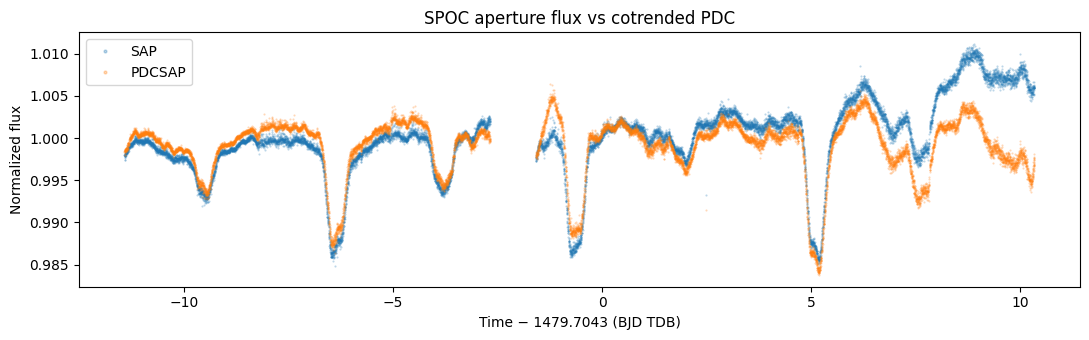

In [24]:
use2 = use & np.isfinite(pdc_flux)
plt.figure(figsize=(11, 3.5))
plt.plot(time[use2] - t0, norm_med(sap_flux[use2]), ".", ms=1, alpha=0.3, label="SAP")
plt.plot(time[use2] - t0, norm_med(pdc_flux[use2]), ".", ms=1, alpha=0.3, label="PDCSAP")
plt.xlabel(f"Time − {t0:.4f} (BJD TDB)")
plt.ylabel("Normalized flux")
plt.title("SPOC aperture flux vs cotrended PDC")
plt.legend(markerscale=4)
plt.tight_layout()